# Milestone 2 — Preprocessing and Augmentation

**Project:** Intelligent Diabetic Retinopathy Detection and Progress Monitoring Using AI/ML

---

> ### ⚠️ Academic prototype — not a medical device
> Screening-support demonstration only. Not clinically validated. Not for diagnosis.

---

## Why this milestone exists

Milestone 1 measured two facts that make preprocessing unavoidable:

| Fact from your data | Consequence |
|---|---|
| Widths span **640 → 4288 px** (6.7×) | The network needs one fixed input size |
| Every image is a retinal disc on a **black rectangle**, and the amount of black varies | Resizing without cropping first means the retina fills a *different fraction* of each frame — the same lesion appears at different scales |

The second point is the subtle one, and it's the part worth explaining in your
report. Resizing alone gives you uniform *image* size but not uniform
*magnification*. Cropping first fixes that.

## The pipeline

```
read → crop black borders → pad to square → [optional CLAHE] → resize to 300×300
                                                                      │
                                          ┌───────────────────────────┘
                                          ▼
                        cached to disk as uint8 PNG (once)
                                          │
                    per epoch ────────────┴──────────►  augment → float32 → ImageNet normalise
```

Two stages, deliberately separated:

- **`src/data/preprocess.py`** — deterministic, expensive, runs **once** and is cached
- **`src/data/transforms.py`** — random, cheap, runs **every epoch**

That separation is what makes caching possible, and caching is what keeps your
RTX 3050 busy instead of waiting on PNG decoding.

## What you'll produce here

| Output | Purpose |
|---|---|
| `reports/figures/m2_crop_threshold_sweep.png` | Justifies your `border_tol` choice |
| `reports/figures/m2_crop_demo.png` | Report figure: cropping in action |
| `reports/figures/m2_clahe_comparison.png` | Report figure: the CLAHE ablation |
| `reports/figures/m2_pipeline_before_after.png` | Report figure: raw vs final, per class |
| `reports/figures/m2_augmentation_grid.png` | Report figure: what the model actually sees |
| `data/interim/train_300/` | 3,662 cached images for Milestones 4–6 |


## 1. Setup

Same setup cell as Milestone 1. Run it first, every time you open this notebook.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

assert (PROJECT_ROOT / "src").is_dir(), f"src/ not found under {PROJECT_ROOT}"

%load_ext autoreload
%autoreload 2

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.inspect import load_labels, pick_samples_per_class
from src.data.preprocess import (
    apply_clahe,
    black_fraction,
    bgr_to_rgb,
    cache_dir_for,
    crop_black_borders,
    pad_to_square,
    preprocess_from_config,
    read_image,
    resize_image,
)
from src.utils.config import class_names, ensure_dirs, get_path, load_config
from src.utils.seed import set_seed

cfg = load_config()
SEED = cfg["project"]["seed"]
set_seed(SEED)

DS          = cfg["dataset"]
ID_COL      = DS["id_col"]
LABEL_COL   = DS["label_col"]
IMAGE_EXT   = DS["image_ext"]
CLASS_NAMES = class_names(cfg)

PP        = cfg["preprocessing"]
SIZE      = PP["image_size"]
TOL       = PP["border_tol"]

APTOS_DIR  = get_path(cfg, "aptos_dir")
IMAGES_DIR = APTOS_DIR / DS["train_images"]
CACHE_DIR  = cache_dir_for(cfg, get_path(cfg, "interim_dir"))

ensure_dirs(cfg, "reports_dir", "figures_dir", "interim_dir")
REPORTS_DIR = get_path(cfg, "reports_dir")
FIGURES_DIR = get_path(cfg, "figures_dir")

plt.rcParams["figure.dpi"] = 110

df = load_labels(APTOS_DIR / DS["train_csv"], ID_COL, LABEL_COL)

print(f"Images        : {len(df)}")
print(f"Target size   : {SIZE}x{SIZE}")
print(f"Border tol    : {TOL}")
print(f"Pad to square : {PP.get('pad_to_square', True)}")
print(f"CLAHE         : {PP['use_clahe']}")
print(f"Cache dir     : {CACHE_DIR}")

Images        : 3662
Target size   : 300x300
Border tol    : 7
Pad to square : True
CLAHE         : False
Cache dir     : C:\Users\ishra\Downloads\dr_project\dr_project\data\interim\train_300


## 2. How much of a raw image is black?

Before fixing the problem, measure it. This scans a sample of images and reports
what fraction of each is (near) black, before and after cropping.

The "reclaimed" number is your justification for cropping, stated quantitatively
rather than as an assertion. Put the mean in your report.

In [2]:
from src.data.preprocess import crop_stats

N_SCAN = 60   # raising this is slow: these are full-resolution images

rng = np.random.default_rng(SEED)
scan_ids = rng.choice(df[ID_COL].to_numpy(), size=min(N_SCAN, len(df)), replace=False)

rows = []
for image_id in scan_ids:
    try:
        raw = read_image(IMAGES_DIR / f"{image_id}{IMAGE_EXT}")
    except ValueError as exc:
        print("skipped", image_id, exc)
        continue
    before, after = crop_stats(raw, tol=TOL)
    cropped = crop_black_borders(raw, tol=TOL)
    rows.append({
        "id": image_id,
        "raw_h": raw.shape[0], "raw_w": raw.shape[1],
        "crop_h": cropped.shape[0], "crop_w": cropped.shape[1],
        "black_before": round(before, 4),
        "black_after": round(after, 4),
        "area_kept": round(cropped.shape[0] * cropped.shape[1] / (raw.shape[0] * raw.shape[1]), 4),
    })

crop_df = pd.DataFrame(rows)
display(crop_df.head(8))

print(f"\nSampled {len(crop_df)} images")
print(f"Black pixels BEFORE crop : {crop_df['black_before'].mean():.1%} "
      f"(range {crop_df['black_before'].min():.1%} - {crop_df['black_before'].max():.1%})")
print(f"Black pixels AFTER crop  : {crop_df['black_after'].mean():.1%}")
print(f"Pixels discarded by crop : {1 - crop_df['area_kept'].mean():.1%} of the raw image, on average")
print("\nNote how much the BEFORE range varies - that variation is exactly why")
print("resizing without cropping gives inconsistent magnification.")

crop_df.to_csv(REPORTS_DIR / "m2_crop_statistics.csv", index=False)
print(f"\nSaved -> {(REPORTS_DIR / 'm2_crop_statistics.csv').relative_to(PROJECT_ROOT)}")

,id,raw_h,raw_w,crop_h,crop_w,black_before,black_after,area_kept
0,c0a0828e01b4,2136,3216,2136,2708,0.2540,0.1141,0.8420
1,10fca1abf338,1226,1844,1226,1509,0.2846,0.1258,0.8183
2,486e852a3b4d,614,819,614,760,0.2025,0.1406,0.9280
3,5c8482926a08,2136,3216,2136,2730,0.2536,0.1208,0.8489
4,b0b3b16fc305,1050,1050,1050,1050,0.2077,0.2077,1.0000
5,c56e65f74187,1958,2588,1958,2588,0.0015,0.0015,1.0000
6,d2dc86021c67,1050,1050,1050,1050,0.2086,0.2086,1.0000
7,6d7d26025122,2588,3388,2556,3339,0.2441,0.2234,0.9734



Sampled 60 images
Black pixels BEFORE crop : 21.4% (range 0.0% - 52.7%)
Black pixels AFTER crop  : 15.4%
Pixels discarded by crop : 7.7% of the raw image, on average

Note how much the BEFORE range varies - that variation is exactly why
resizing without cropping gives inconsistent magnification.

Saved -> reports\m2_crop_statistics.csv


## 3. Choosing the crop threshold

`border_tol` decides what counts as "black". Get it wrong in either direction
and you damage the data:

- **too low** → dark border survives the crop, and you're back to wasted pixels
- **too high** → the crop eats into the dark periphery of the retina, where
  haemorrhages often sit

Don't accept my default of 7 — verify it on *your* images. The cell below sweeps
several thresholds on one image so you can see the effect.

Saved -> reports\figures\m2_crop_threshold_sweep.png


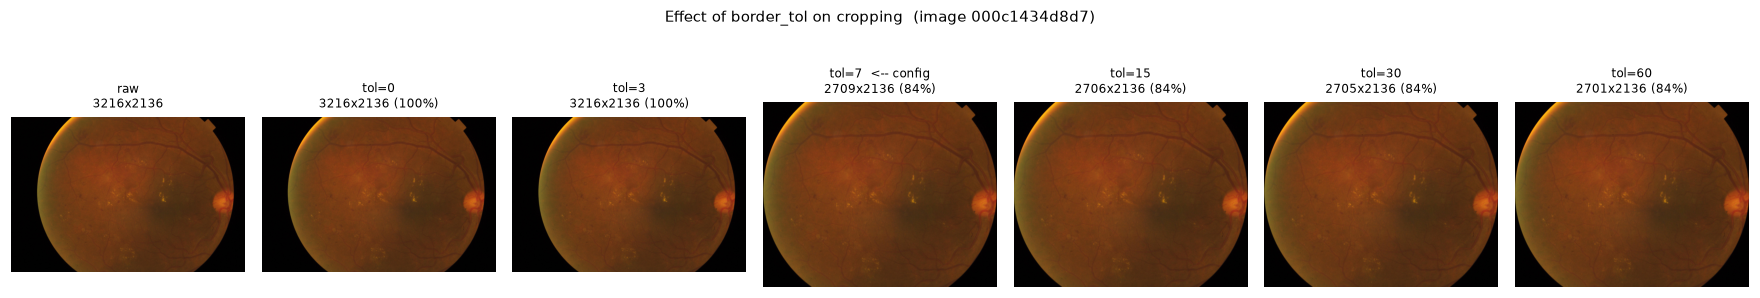

What to look for: the smallest tol whose crop has no visible black frame.
If tol=7 still leaves a dark band on your images, raise it in configs/config.yaml.
If the retina looks clipped at the edges, lower it.


In [3]:
TEST_ID = df[ID_COL].iloc[0]     # change this to inspect a different image
TOLS = [0, 3, 7, 15, 30, 60]

raw = read_image(IMAGES_DIR / f"{TEST_ID}{IMAGE_EXT}")

fig, axes = plt.subplots(1, len(TOLS) + 1, figsize=(2.3 * (len(TOLS) + 1), 3.0))

axes[0].imshow(bgr_to_rgb(raw))
axes[0].set_title(f"raw\n{raw.shape[1]}x{raw.shape[0]}", fontsize=8)
axes[0].axis("off")

for ax, tol in zip(axes[1:], TOLS):
    cropped = crop_black_borders(raw, tol=tol)
    ax.imshow(bgr_to_rgb(cropped))
    kept = cropped.shape[0] * cropped.shape[1] / (raw.shape[0] * raw.shape[1])
    marker = "  <-- config" if tol == TOL else ""
    ax.set_title(f"tol={tol}{marker}\n{cropped.shape[1]}x{cropped.shape[0]} ({kept:.0%})",
                 fontsize=8)
    ax.axis("off")

fig.suptitle(f"Effect of border_tol on cropping  (image {TEST_ID})", fontsize=10)
fig.tight_layout(rect=[0, 0, 1, 0.94])
out = FIGURES_DIR / "m2_crop_threshold_sweep.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
print(f"Saved -> {out.relative_to(PROJECT_ROOT)}")
plt.show()

print("What to look for: the smallest tol whose crop has no visible black frame.")
print("If tol=7 still leaves a dark band on your images, raise it in configs/config.yaml.")
print("If the retina looks clipped at the edges, lower it.")

## 4. Cropping and squaring, step by step

Four panels showing each stage on one image. Watch the shape annotations — the
aspect ratio changes at the crop, then becomes 1:1 at the pad, and only then do
we resize. Doing it in the other order would stretch the retina.

Saved -> reports\figures\m2_crop_demo.png


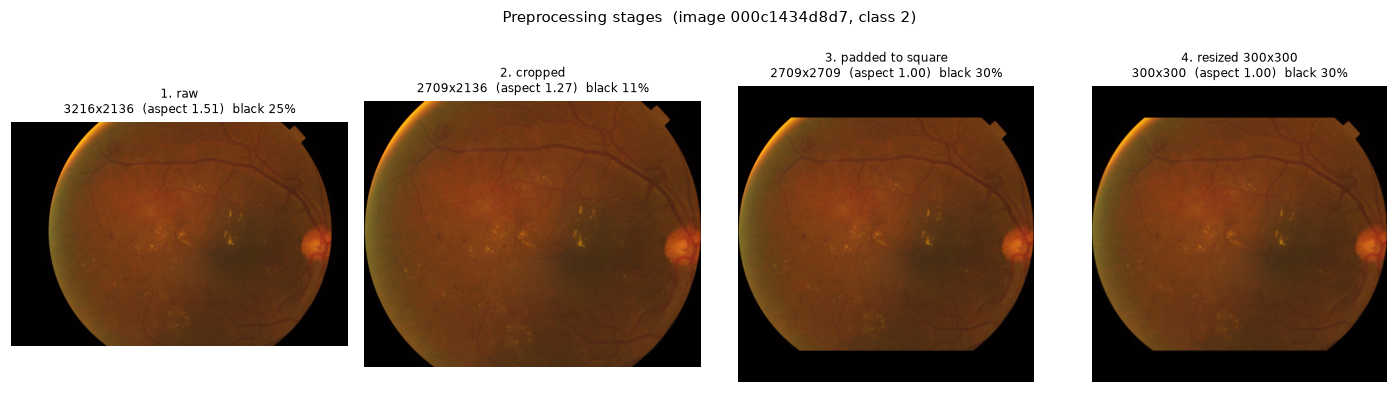

In [4]:
stages = []
stages.append(("1. raw", raw))
cropped = crop_black_borders(raw, tol=TOL)
stages.append(("2. cropped", cropped))
squared = pad_to_square(cropped)
stages.append(("3. padded to square", squared))
final = resize_image(squared, SIZE)
stages.append((f"4. resized {SIZE}x{SIZE}", final))

fig, axes = plt.subplots(1, 4, figsize=(13, 3.6))
for ax, (title, img) in zip(axes, stages):
    ax.imshow(bgr_to_rgb(img))
    h, w = img.shape[:2]
    ax.set_title(f"{title}\n{w}x{h}  (aspect {w/h:.2f})  black {black_fraction(img, TOL):.0%}",
                 fontsize=8)
    ax.axis("off")

fig.suptitle(f"Preprocessing stages  (image {TEST_ID}, class "
             f"{int(df.loc[df[ID_COL] == TEST_ID, LABEL_COL].iloc[0])})", fontsize=10)
fig.tight_layout(rect=[0, 0, 1, 0.92])
out = FIGURES_DIR / "m2_crop_demo.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
print(f"Saved -> {out.relative_to(PROJECT_ROOT)}")
plt.show()

## 5. CLAHE — enhancement or noise amplifier?

CLAHE (Contrast Limited Adaptive Histogram Equalisation) boosts *local* contrast,
which can make faint microaneurysms easier to see. It is very common in published
DR pipelines.

It is applied only to the **L (lightness)** channel in LAB colour space, so hue
and saturation are untouched. That matters: haemorrhages are dark *red* and
exudates are pale *yellow*, and plain RGB histogram equalisation would shift those
colours.

`clip_limit` caps the amplification. Without it, CLAHE turns sensor noise in the
dark periphery into convincing-looking fake lesions.

**Whether it helps is an empirical question, not an assumption.** That's why it's
a config flag, and why it becomes an ablation row in Milestone 6. Look at the
panels below and form a hypothesis — then let the QWK numbers decide.

Saved -> reports\figures\m2_clahe_comparison.png


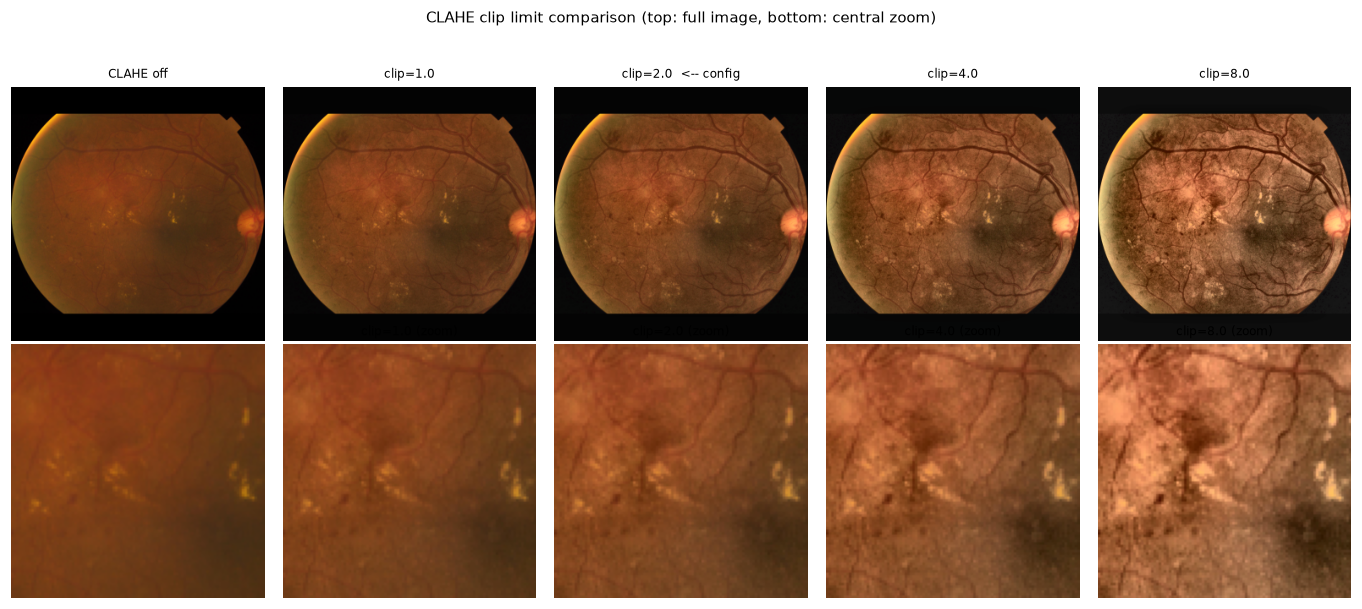

Judge the ZOOM row, not the full image.
Higher clip = more local contrast, but also more amplified noise.
clip=8 usually looks obviously over-processed - that is the point of showing it.


In [5]:
CLIPS = [1.0, 2.0, 4.0, 8.0]

base = pad_to_square(crop_black_borders(raw, tol=TOL))
base_small = resize_image(base, SIZE)

fig, axes = plt.subplots(2, len(CLIPS) + 1, figsize=(2.5 * (len(CLIPS) + 1), 5.6))

def show(ax, img, title):
    ax.imshow(bgr_to_rgb(img)); ax.set_title(title, fontsize=8); ax.axis("off")

show(axes[0, 0], base_small, "CLAHE off")
# Zoom into the centre so you can judge texture, not just overall brightness.
c = SIZE // 2; z = SIZE // 6
show(axes[1, 0], base_small[c-z:c+z, c-z:c+z], "off (zoom)")

for col, clip in enumerate(CLIPS, start=1):
    enhanced = resize_image(apply_clahe(base, clip_limit=clip,
                                        tile_grid=PP["clahe_tile_grid"]), SIZE)
    marker = "  <-- config" if clip == PP["clahe_clip_limit"] else ""
    show(axes[0, col], enhanced, f"clip={clip}{marker}")
    show(axes[1, col], enhanced[c-z:c+z, c-z:c+z], f"clip={clip} (zoom)")

fig.suptitle("CLAHE clip limit comparison (top: full image, bottom: central zoom)", fontsize=10)
fig.tight_layout(rect=[0, 0, 1, 0.94])
out = FIGURES_DIR / "m2_clahe_comparison.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
print(f"Saved -> {out.relative_to(PROJECT_ROOT)}")
plt.show()

print("Judge the ZOOM row, not the full image.")
print("Higher clip = more local contrast, but also more amplified noise.")
print("clip=8 usually looks obviously over-processed - that is the point of showing it.")

## 6. The full pipeline, raw vs final, one row per class

This is the headline preprocessing figure for your report. Left column is the raw
photograph, right column is exactly what the network will receive.

Saved -> reports\figures\m2_pipeline_before_after.png


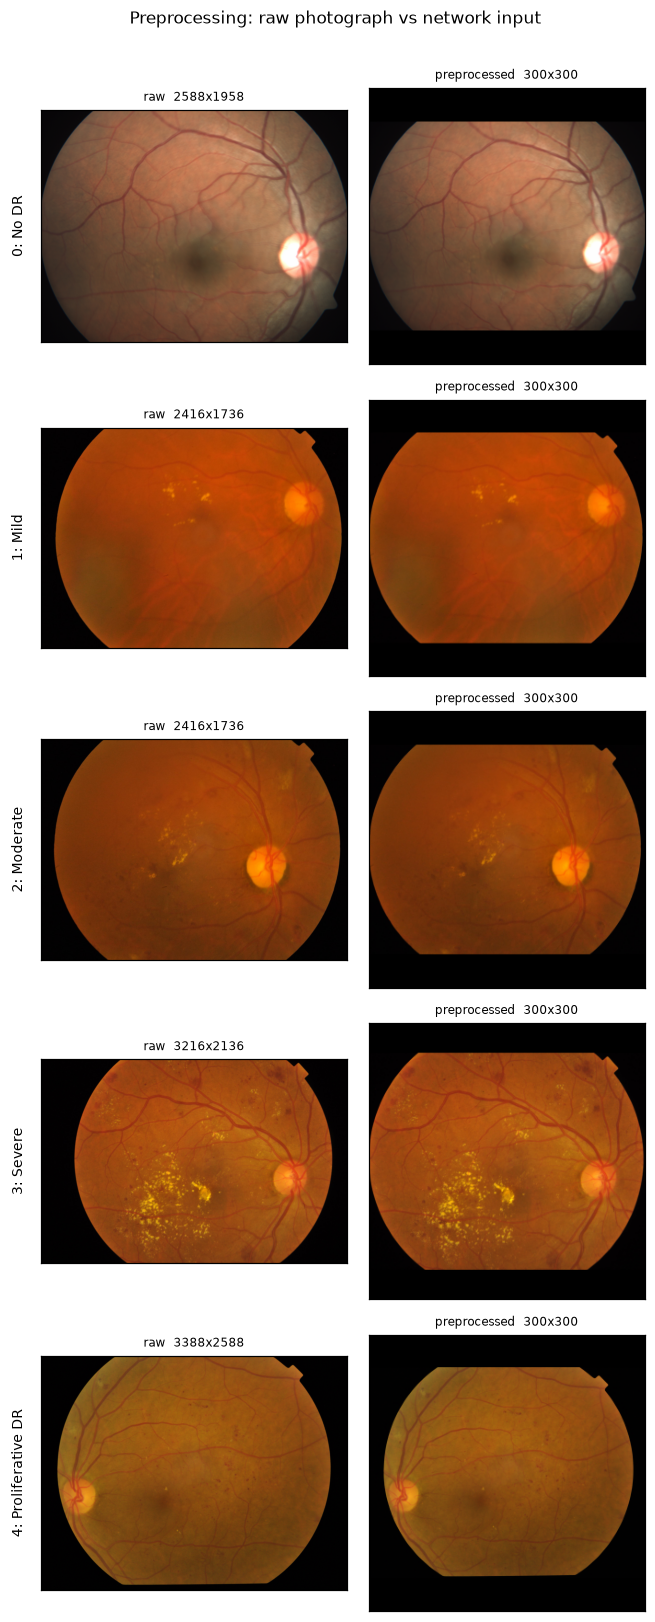

In [6]:
PER_CLASS = 1
samples = pick_samples_per_class(df, ID_COL, LABEL_COL, per_class=PER_CLASS, seed=SEED)

n = len(CLASS_NAMES)
fig, axes = plt.subplots(n, 2, figsize=(6.2, 3.0 * n))

for row, label in enumerate(range(n)):
    subset = samples[samples[LABEL_COL] == label]
    if subset.empty:
        axes[row, 0].axis("off"); axes[row, 1].axis("off")
        continue
    image_id = subset[ID_COL].iloc[0]
    src = read_image(IMAGES_DIR / f"{image_id}{IMAGE_EXT}")
    dst = preprocess_from_config(src, cfg)

    axes[row, 0].imshow(bgr_to_rgb(src))
    axes[row, 0].set_title(f"raw  {src.shape[1]}x{src.shape[0]}", fontsize=8)
    axes[row, 1].imshow(bgr_to_rgb(dst))
    axes[row, 1].set_title(f"preprocessed  {SIZE}x{SIZE}", fontsize=8)

    for col in (0, 1):
        axes[row, col].set_xticks([]); axes[row, col].set_yticks([])
    axes[row, 0].set_ylabel(f"{label}: {CLASS_NAMES[label]}", fontsize=9, rotation=90, labelpad=10)

fig.suptitle("Preprocessing: raw photograph vs network input", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.975])
out = FIGURES_DIR / "m2_pipeline_before_after.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
print(f"Saved -> {out.relative_to(PROJECT_ROOT)}")
plt.show()

## 7. Augmentation — what the model actually sees

Now the per-epoch stage. `build_transforms(cfg, train=True)` returns the random
pipeline; `train=False` returns normalisation only.

**Use `train=False` for validation, test, and the Streamlit app.** Augmenting at
inference time makes predictions non-deterministic and breaks the correspondence
between the Grad-CAM heatmap and the image the user uploaded.

The augmentations are deliberately gentle on colour (hue is fixed at 0) and
generous on geometry. A fundus photograph has no canonical orientation — the
camera can be rotated, and left and right eyes are mirror images — so flips and
rotation are free, label-preserving variety. Colour is different: lesion identity
is partly *in* the colour, so shifting hue would corrupt the label.

In [7]:
try:
    import torch
    from src.data.transforms import build_transforms, denormalize, describe_transforms

    train_tf = build_transforms(cfg, train=True)
    eval_tf  = build_transforms(cfg, train=False)

    print("TRAIN pipeline:")
    print(describe_transforms(train_tf))
    print("\nEVAL pipeline (also used by the app):")
    print(describe_transforms(eval_tf))

    TORCH_OK = True
except ImportError as exc:
    print("PyTorch/torchvision not importable:", exc)
    print("Install it, then re-run this cell. Sections 1-6 do not need it.")
    TORCH_OK = False

TRAIN pipeline:
  1. ToImage: ToImage()
  2. RandomHorizontalFlip: RandomHorizontalFlip(p=0.5)
  3. RandomVerticalFlip: RandomVerticalFlip(p=0.5)
  4. RandomAffine: RandomAffine(degrees=[-15.0, 15.0], scale=(0.9, 1.0), interpolation=InterpolationMode.BILINEAR, fill=0)
  5. ColorJitter: ColorJitter(brightness=(0.85, 1.15), contrast=(0.85, 1.15), saturation=(0.9, 1.1))
  6. ToDtype: ToDtype(scale=True)
  7. Normalize: Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)

EVAL pipeline (also used by the app):
  1. ToImage: ToImage()
  2. ToDtype: ToDtype(scale=True)
  3. Normalize: Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)


Saved -> reports\figures\m2_augmentation_grid.png


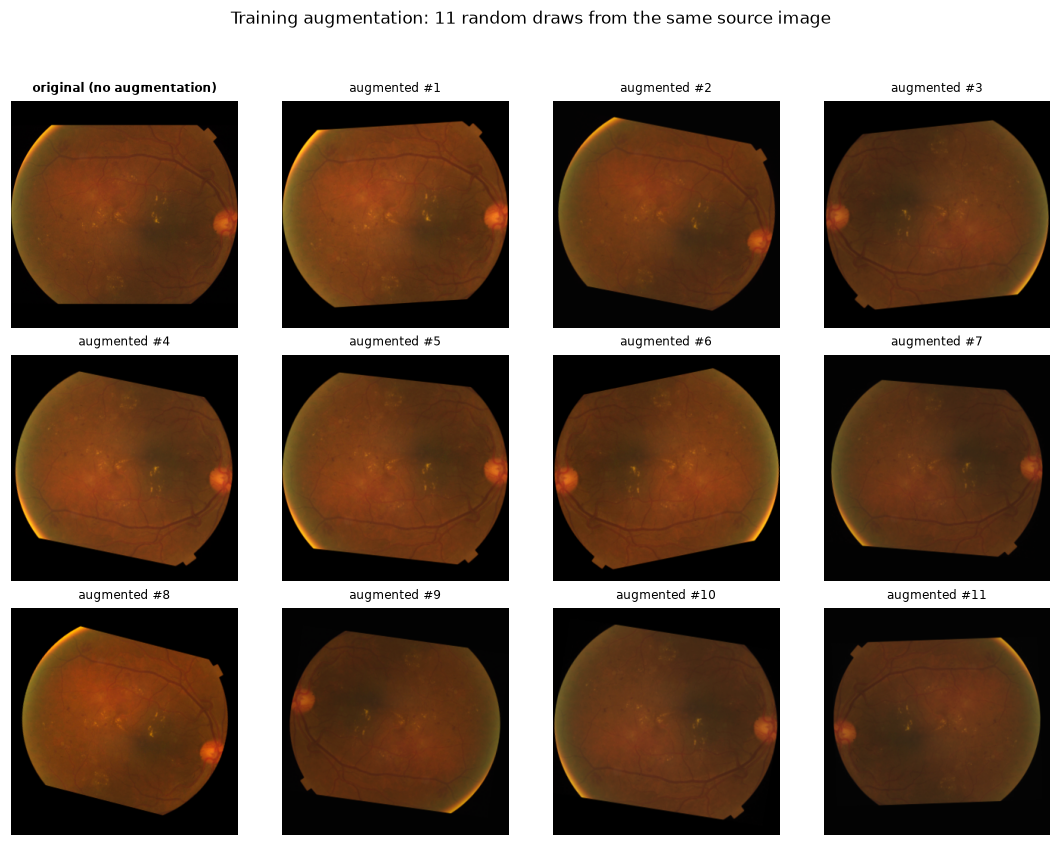

Sanity checks to make with your own eyes:
  - every panel is still recognisably a fundus photograph
  - colours have NOT shifted (no green or purple retinas)
  - rotation corners are black, matching the real camera surround
  - if any panel looks destroyed, your augmentation is too aggressive


In [8]:
if TORCH_OK:
    torch.manual_seed(SEED)

    # One preprocessed image, in RGB, as the Dataset will provide it.
    base_rgb = bgr_to_rgb(preprocess_from_config(raw, cfg))

    N_AUG = 11
    fig, axes = plt.subplots(3, 4, figsize=(10, 7.8))
    axes = axes.ravel()

    axes[0].imshow(base_rgb)
    axes[0].set_title("original (no augmentation)", fontsize=8, fontweight="bold")
    axes[0].axis("off")

    for i in range(1, N_AUG + 1):
        tensor = train_tf(base_rgb)               # -> normalised float32 CHW
        axes[i].imshow(denormalize(tensor, cfg))  # -> uint8 HWC for display
        axes[i].set_title(f"augmented #{i}", fontsize=8)
        axes[i].axis("off")

    fig.suptitle("Training augmentation: 11 random draws from the same source image",
                 fontsize=11)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    out = FIGURES_DIR / "m2_augmentation_grid.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    print(f"Saved -> {out.relative_to(PROJECT_ROOT)}")
    plt.show()

    print("Sanity checks to make with your own eyes:")
    print("  - every panel is still recognisably a fundus photograph")
    print("  - colours have NOT shifted (no green or purple retinas)")
    print("  - rotation corners are black, matching the real camera surround")
    print("  - if any panel looks destroyed, your augmentation is too aggressive")

In [9]:
if TORCH_OK:
    # Verify the tensor contract the model will rely on.
    t_train = train_tf(base_rgb)
    t_eval  = eval_tf(base_rgb)

    print(f"train tensor : shape {tuple(t_train.shape)}  dtype {t_train.dtype}")
    print(f"eval  tensor : shape {tuple(t_eval.shape)}  dtype {t_eval.dtype}")
    print(f"eval  range  : [{t_eval.min():.3f}, {t_eval.max():.3f}]  "
          f"mean {t_eval.mean():.3f}")

    assert t_eval.shape == (3, SIZE, SIZE), "unexpected tensor shape"
    assert t_eval.dtype == torch.float32, "tensor must be float32"

    # After ImageNet normalisation, values sit roughly in [-2.2, 2.7], NOT [0,1].
    # Seeing [0,1] here means Normalize was skipped; seeing [0,255] means
    # ToDtype(scale=True) was skipped. Both silently wreck training.
    if -0.05 <= t_eval.min() and t_eval.max() <= 1.05:
        print("\nWARNING: values look like [0,1] - is Normalize missing?")
    elif t_eval.max() > 10:
        print("\nWARNING: values look like [0,255] - is scale=True missing?")
    else:
        print("\nNormalisation looks correct (ImageNet-scaled).")

    # Determinism: eval must give the same tensor twice, train must not.
    same_eval  = torch.allclose(eval_tf(base_rgb), t_eval)
    torch.manual_seed(SEED + 1)
    diff_train = not torch.allclose(train_tf(base_rgb), t_train)
    print(f"eval transform deterministic : {same_eval}   (must be True)")
    print(f"train transform randomised   : {diff_train}   (must be True)")

train tensor : shape (3, 300, 300)  dtype torch.float32
eval  tensor : shape (3, 300, 300)  dtype torch.float32
eval  range  : [-2.118, 2.232]  mean -1.233

Normalisation looks correct (ImageNet-scaled).
eval transform deterministic : True   (must be True)
train transform randomised   : True   (must be True)


## 8. Cache the whole dataset

Now run the deterministic part once over all 3,662 images and write the results to
`data/interim/train_300/`.

Do it from a **terminal**, not from this notebook — the script uses multiple
processes, and process pools launched from Jupyter on Windows can hang:

```powershell
python -m scripts.m2_cache_images --limit 20      # trial run first
python -m scripts.m2_cache_images --workers 4     # the real thing
```

Expect a few minutes and roughly 100–200 MB of disk. The script is restartable:
re-running it skips images already cached.

**If you later change `border_tol`, `pad_to_square`, or `use_clahe`, the cache is
stale.** Rebuild with `--force`. The settings that produced the cache are recorded
in `data/interim/train_300/_cache_meta.json`, and the next cell checks them
against your current config.

In [11]:
import json

meta_path = CACHE_DIR / "_cache_meta.json"
cached = sorted(CACHE_DIR.glob(f"*{IMAGE_EXT}"))

print(f"Cache directory : {CACHE_DIR}")
print(f"Cached images   : {len(cached)} / {len(df)}")

if not cached:
    print("\nCache is empty. Run this in a terminal:")
    print("   python -m scripts.m2_cache_images --workers 4")
elif len(cached) < len(df):
    print(f"\nCache is INCOMPLETE ({len(df) - len(cached)} missing). Re-run:")
    print("   python -m scripts.m2_cache_images --workers 4")
else:
    size_mb = sum(f.stat().st_size for f in cached) / 1e6
    print(f"Cache size      : {size_mb:.1f} MB "
          f"(mean {size_mb * 1000 / len(cached):.0f} KB per image)")

    if meta_path.is_file():
        meta = json.loads(meta_path.read_text())
        stale = {k: (v, PP.get(k)) for k, v in meta["preprocessing"].items()
                 if PP.get(k) != v}
        if stale:
            print("\nWARNING: cache was built with DIFFERENT settings:")
            for key, (was, now) in stale.items():
                print(f"   {key}: cached={was!r}  config={now!r}")
            print("   Rebuild: python -m scripts.m2_cache_images --force --workers 4")
        else:
            print("\nCache settings match the current config. Good.")
    else:
        print("\nNo _cache_meta.json - cache predates metadata tracking.")

Cache directory : C:\Users\ishra\Downloads\dr_project\dr_project\data\interim\train_300
Cached images   : 3662 / 3662
Cache size      : 363.3 MB (mean 99 KB per image)

Cache settings match the current config. Good.


## 9. Verify the cache is actually usable

Load a few cached images back and confirm they are what you expect. A cache that
silently contains wrong-sized or all-black images would poison every training run
downstream, and you would spend a long time blaming the model.

Checked 12 cached image(s)
All checked images are the right size and not blank.


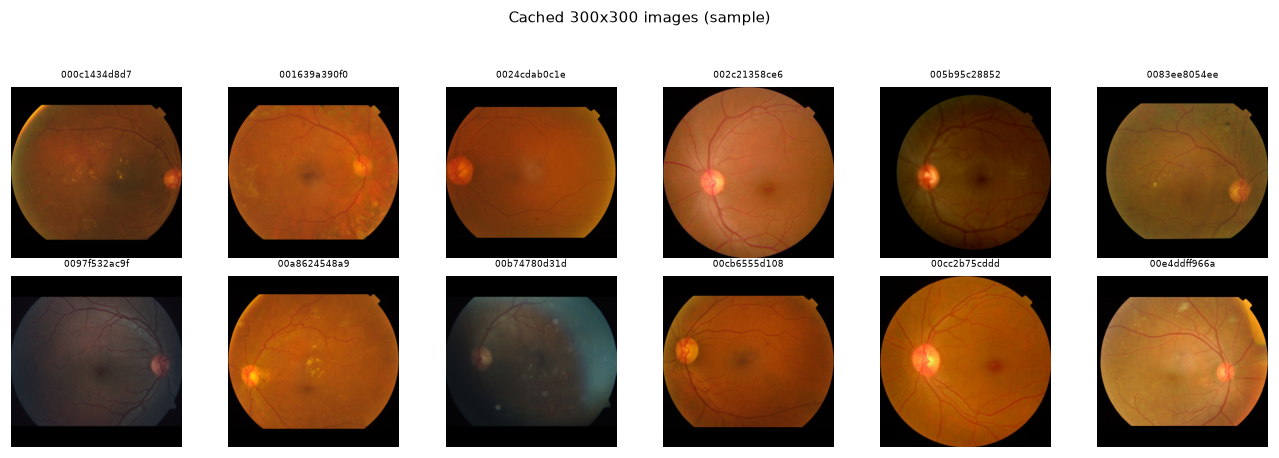

In [12]:
if cached:
    check = cached[: min(12, len(cached))]
    problems = []

    for path in check:
        img = read_image(path)
        if img.shape[:2] != (SIZE, SIZE):
            problems.append(f"{path.name}: wrong size {img.shape[:2]}")
        if black_fraction(img, TOL) > 0.80:
            problems.append(f"{path.name}: {black_fraction(img, TOL):.0%} black - likely broken")

    print(f"Checked {len(check)} cached image(s)")
    if problems:
        print("PROBLEMS:")
        for p in problems:
            print("  -", p)
    else:
        print("All checked images are the right size and not blank.")

    fig, axes = plt.subplots(2, 6, figsize=(12, 4.2))
    for ax, path in zip(axes.ravel(), check):
        ax.imshow(bgr_to_rgb(read_image(path)))
        ax.set_title(path.stem, fontsize=6)
        ax.axis("off")
    for ax in axes.ravel()[len(check):]:
        ax.axis("off")
    fig.suptitle(f"Cached {SIZE}x{SIZE} images (sample)", fontsize=10)
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()
else:
    print("Nothing cached yet - run the caching script first (section 8).")

## 10. Milestone 2 summary

In [13]:
print("=" * 70)
print("  MILESTONE 2 SUMMARY")
print("=" * 70)
print(f"Target size            : {SIZE}x{SIZE} (same for all three architectures)")
print(f"Crop black borders     : {PP['crop_black_borders']}  (border_tol={TOL})")
print(f"Pad to square          : {PP.get('pad_to_square', True)}")
print(f"CLAHE                  : {PP['use_clahe']}  (clip={PP['clahe_clip_limit']})")
print(f"Normalisation           : ImageNet mean={PP['mean']} std={PP['std']}")
if len(crop_df):
    print(f"Mean black area before : {crop_df['black_before'].mean():.1%}")
    print(f"Mean black area after  : {crop_df['black_after'].mean():.1%}")
    print(f"Mean pixels discarded  : {1 - crop_df['area_kept'].mean():.1%}")
print(f"Cached images          : {len(cached)} / {len(df)}")
aug = cfg.get("augmentation", {})
print(f"Augmentation           : hflip {aug.get('hflip_p')}, vflip {aug.get('vflip_p')}, "
      f"rotate +/-{aug.get('rotate_degrees')} deg,")
print(f"                         brightness {aug.get('brightness')}, contrast {aug.get('contrast')}, "
      f"saturation {aug.get('saturation')}, hue {aug.get('hue')}")
print(f"Random seed            : {SEED}")
print("=" * 70)
print("\nFigures written:")
for f in sorted(FIGURES_DIR.glob("m2_*.png")):
    print("  ", f.relative_to(PROJECT_ROOT))

  MILESTONE 2 SUMMARY
Target size            : 300x300 (same for all three architectures)
Crop black borders     : True  (border_tol=7)
Pad to square          : True
CLAHE                  : False  (clip=2.0)
Normalisation           : ImageNet mean=[0.485, 0.456, 0.406] std=[0.229, 0.224, 0.225]
Mean black area before : 21.4%
Mean black area after  : 15.4%
Mean pixels discarded  : 7.7%
Cached images          : 3662 / 3662
Augmentation           : hflip None, vflip None, rotate +/-None deg,
                         brightness None, contrast None, saturation None, hue None
Random seed            : 42

Figures written:
   reports\figures\m2_augmentation_grid.png
   reports\figures\m2_clahe_comparison.png
   reports\figures\m2_crop_demo.png
   reports\figures\m2_crop_threshold_sweep.png
   reports\figures\m2_pipeline_before_after.png


---

## Milestone 2 complete

Commit it:

```powershell
git add .
git commit -m "Milestone 2: preprocessing pipeline, augmentation, image cache"
git tag m2
```

**Next: Milestone 3 — stratified train/validation/test split.**

Short milestone, but the one where a mistake is most expensive and least visible.
The two things it has to guarantee:

1. **Stratification.** With Severe at 5.3%, a naive random split can leave that
   class badly under-represented in validation, making your model-selection
   metric noise.
2. **No leakage.** Every image ID appears in exactly one split, and the split is
   written to CSV so all three architectures train and evaluate on identical data.
   Without that, your Milestone 6 comparison table is meaningless.

Before moving on, tell your mentor the mean black-area numbers from section 2 and
whether `border_tol=7` looked right on your images.
